# The Power of Images: Visual Analysis of Trump vs AOC
## How Politicians Use Photos to Shape Their Message

A picture is worth a thousand words -- and in political social media, the images politicians choose to share are a powerful tool for persuasion and communication. Whether it is a photo of a packed rally, an official portrait, or an infographic about policy, every image is a deliberate choice designed to shape how the audience perceives the politician and their message.

In this notebook, we analyze the **visual strategy** of Trump and AOC on Twitter/X. We ask:
- **How often** does each politician include images in their tweets?
- **What do the images look like?** Are they bright or dark? What colors dominate?
- **Do tweets with images get more attention** than text-only tweets?
- **When** do they post images? Is there a strategic timing pattern?
- **Which image tweets performed best?** What can we learn from the top-performing visual content?

No programming or statistics background is needed. Every concept is explained as it appears.

---

**Key terms you will see in this notebook:**
- **Image / Photo**: A picture attached to a tweet (as opposed to a text-only tweet)
- **Average (mean)**: Add up all the numbers and divide by how many there are
- **Median (middle value)**: Line up all numbers from smallest to largest; the median is the one in the middle
- **Engagement rate**: A measure of how much attention a tweet gets (likes, retweets, replies, etc.) relative to how many people saw it
- **Distribution**: How values are spread out -- for example, are most images bright, or is there a wide range?

In [1]:
# --- Setup: Loading the tools and data we need ---
# (This cell loads the software libraries and styling. You can ignore the technical details.)

import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from PIL import Image
import os

from utils.data_loader import load_tweets, get_images_dir
from utils.plot_helpers import (
    setup_style, get_colors, get_user_label,
    comparative_bar, format_large_numbers
)
from config import FIGURE_SIZE, FIGURE_SIZE_SMALL, FIGURE_SIZE_LARGE, RANDOM_SEED, TARGET_USERS

# Apply consistent style
setup_style()
colors = get_colors()
np.random.seed(RANDOM_SEED)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Setup complete.')

Setup complete.


In [2]:
# --- Load data and discover images ---

df = load_tweets()
images_dir = get_images_dir()

print(f"Images directory: {images_dir}")
print()

# Build image inventory
image_inventory = {}
for user_label in ['trump', 'aoc']:
    user_dir = images_dir / user_label
    if user_dir.exists():
        files = sorted(user_dir.glob('*.jpg'))
        image_inventory[user_label] = files
        print(f"{user_label}: {len(files)} images found")
    else:
        image_inventory[user_label] = []
        print(f"{user_label}: No images directory found")

# Separate tweets that include images from text-only tweets
df_with_images = df[df['image_count'] > 0].copy()
df_without_images = df[df['image_count'] == 0].copy()

print(f"\nTweets with images: {len(df_with_images)} out of {len(df)} total")
for u in ['trump', 'aoc']:
    count = len(df_with_images[df_with_images['user'] == u])
    total = len(df[df['user'] == u])
    print(f"  {get_user_label(u)}: {count} out of {total} tweets include images ({count/total*100:.1f}%)")

Loaded 200 tweets from processed/
Images directory: C:\Users\Ayrton\trump-aoc-netnography\data\images

trump: 28 images found
aoc: 7 images found

Tweets with images: 29 out of 200 total
  Trump (@realDonaldTrump): 25 out of 100 tweets include images (25.0%)
  AOC (@AOC): 4 out of 100 tweets include images (4.0%)


---
## 1. How Often Do They Use Images?

The first question is simple: **how frequently does each politician attach images to their tweets?**

Some politicians rely heavily on text to communicate, while others use images as visual "hooks" to catch people's attention as they scroll through their feed. The choice to include (or not include) an image is itself a strategic decision.

We also look at **media types** -- whether the attached content is a photo, a video, or an animated GIF. Each format serves a different purpose:
- **Photos** capture a single moment or deliver an infographic
- **Videos** allow for longer, more immersive storytelling
- **GIFs** (short animated clips) are often used for humor or emphasis

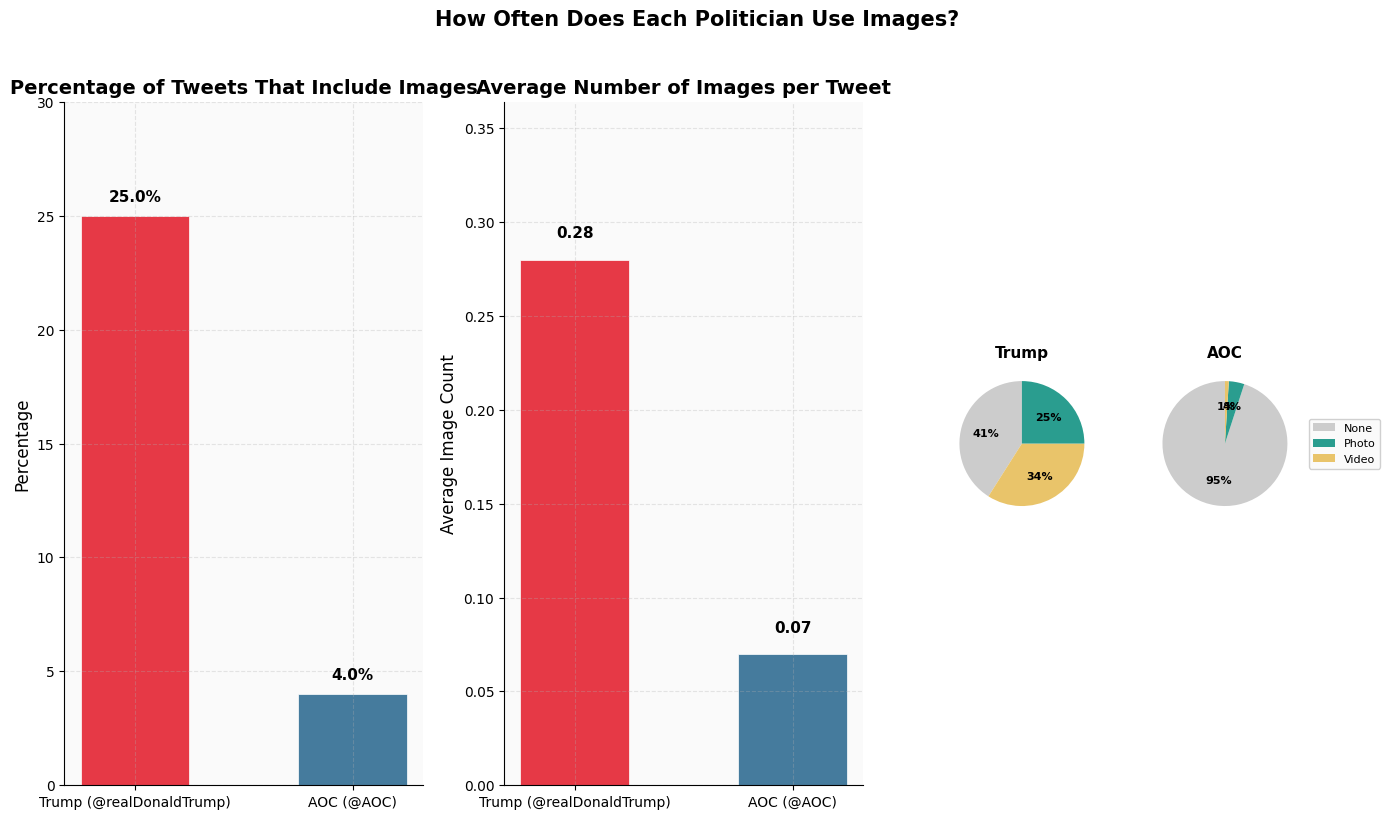


Media type breakdown:

Trump (@realDonaldTrump):
  none: 41 (41.0%)
  video: 34 (34.0%)
  photo: 25 (25.0%)

AOC (@AOC):
  none: 95 (95.0%)
  photo: 4 (4.0%)
  video: 1 (1.0%)


In [3]:
# --- Image frequency comparison ---

fig, axes = plt.subplots(1, 3, figsize=FIGURE_SIZE_LARGE)

users = ['trump', 'aoc']
user_labels = [get_user_label(u) for u in users]

# --- Panel 1: % of tweets containing images ---
ax = axes[0]
pct_with_images = []
for u in users:
    user_total = len(df[df['user'] == u])
    user_with_img = len(df_with_images[df_with_images['user'] == u])
    pct_with_images.append(user_with_img / user_total * 100 if user_total > 0 else 0)

bars = ax.bar(user_labels, pct_with_images, color=[colors[u] for u in users],
              width=0.5, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, pct_with_images):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Percentage of Tweets That Include Images', fontweight='bold')
ax.set_ylabel('Percentage')
ax.set_ylim(0, max(pct_with_images) * 1.2 if max(pct_with_images) > 0 else 10)

# --- Panel 2: Average images per tweet ---
ax = axes[1]
avg_images = [df[df['user'] == u]['image_count'].mean() for u in users]
bars = ax.bar(user_labels, avg_images, color=[colors[u] for u in users],
              width=0.5, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, avg_images):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Average Number of Images per Tweet', fontweight='bold')
ax.set_ylabel('Average Image Count')
ax.set_ylim(0, max(avg_images) * 1.3 if max(avg_images) > 0 else 1)

# --- Panel 3: Media type distribution (pie charts) ---
axes[2].set_visible(False)
gs_inner = axes[2].get_subplotspec().subgridspec(1, 2, wspace=0.3)

pie_colors_map = {
    'none': '#CCCCCC',
    'photo': '#2A9D8F',
    'video': '#E9C46A',
    'animated_gif': '#F4A261',
    'mixed': '#E76F51'
}

for idx, user in enumerate(users):
    ax_pie = fig.add_subplot(gs_inner[0, idx])
    user_data = df[df['user'] == user]
    media_counts = user_data['media_type'].value_counts()
    
    pie_labels = media_counts.index.tolist()
    pie_vals = media_counts.values
    pie_colors = [pie_colors_map.get(str(label).lower(), '#999999') for label in pie_labels]
    
    wedges, texts, autotexts = ax_pie.pie(
        pie_vals, labels=None, autopct='%1.0f%%',
        colors=pie_colors, startangle=90,
        textprops={'fontsize': 8}
    )
    for autotext in autotexts:
        autotext.set_fontweight('bold')
    
    ax_pie.set_title(get_user_label(user).split(' (')[0], fontweight='bold', fontsize=11)
    
    if idx == 1:
        ax_pie.legend(
            [str(l).title() for l in pie_labels],
            loc='center left', bbox_to_anchor=(1.0, 0.5),
            fontsize=8
        )

fig.suptitle('How Often Does Each Politician Use Images?', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Print summary
print("\nMedia type breakdown:")
for u in users:
    print(f"\n{get_user_label(u)}:")
    user_data = df[df['user'] == u]
    counts = user_data['media_type'].value_counts()
    for mt, cnt in counts.items():
        print(f"  {mt}: {cnt} ({cnt/len(user_data)*100:.1f}%)")

### What does this tell us?

The percentage of tweets with images reveals each politician's **visual communication strategy**. A politician who frequently uses images is betting that visual content grabs more attention in a crowded social media feed. A politician who relies more on text may be prioritizing written arguments or statements.

The media type breakdown (photos vs. videos vs. GIFs) adds another layer: video-heavy content suggests a storytelling approach, while photo-heavy content focuses on static visual moments. The balance between these formats reflects different ways of connecting with an audience.

---
## 2. Image Gallery: What Do Their Images Actually Look Like?

Before diving into numbers, it helps to simply **look at the images**. Browsing through a sample of each politician's images gives us an intuitive sense of their visual style.

Ask yourself as you look: Are these professional photos or casual snapshots? Rally crowds or policy graphics? Formal settings or personal moments? Every choice communicates something about the politician's desired image.

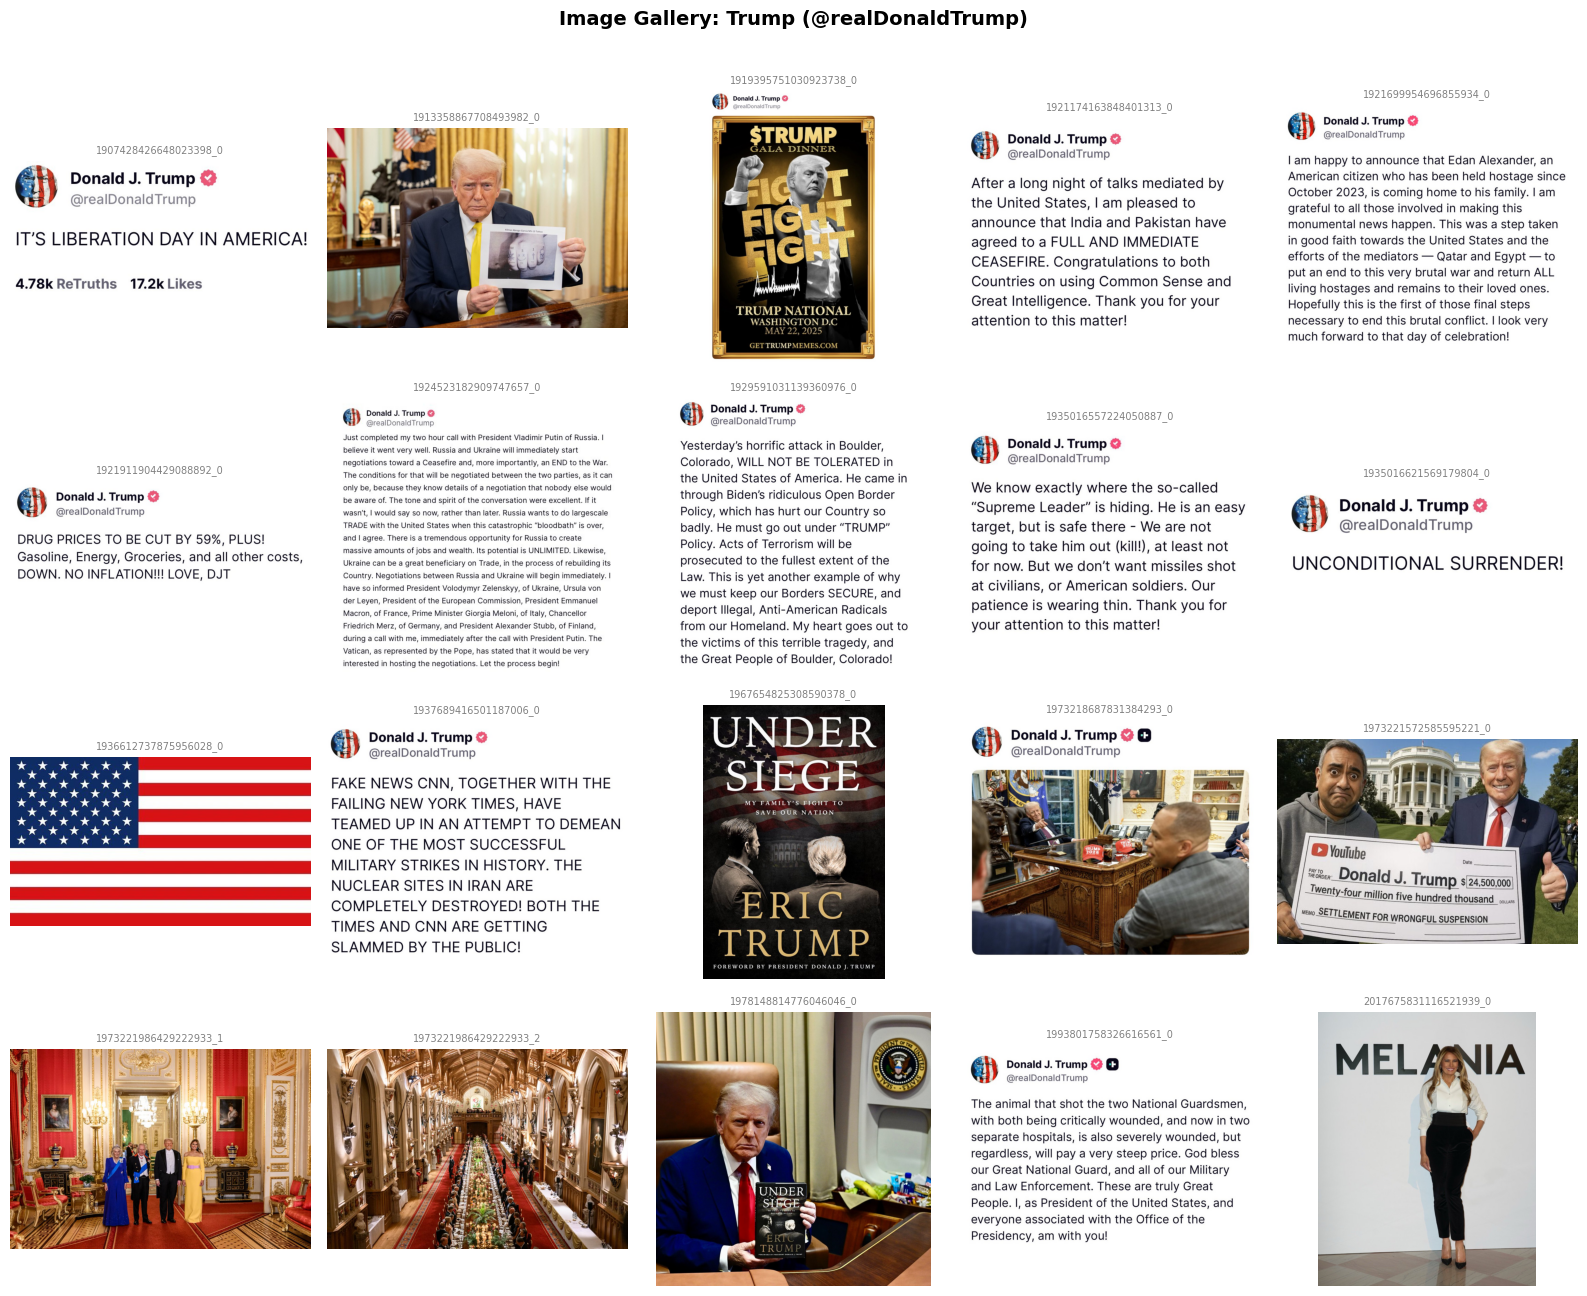

  Showing 20 of 28 total images



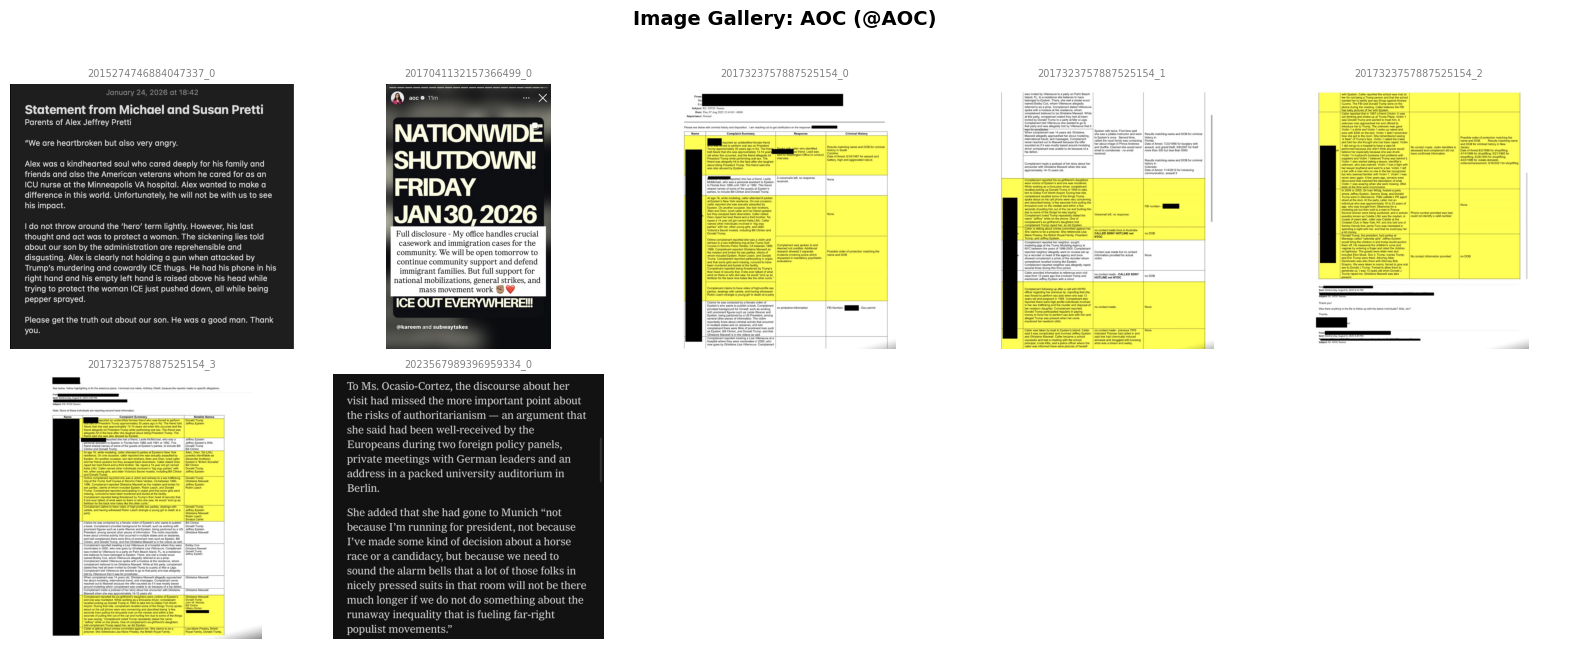

  Showing 7 of 7 total images



In [4]:
# --- Image gallery grid ---
# We show up to 20 images per politician, evenly spaced from their collection.

MAX_IMAGES = 20
GRID_COLS = 5
GRID_ROWS = 4

for user in ['trump', 'aoc']:
    user_images = image_inventory.get(user, [])
    if len(user_images) == 0:
        print(f"No images available for {get_user_label(user)}")
        continue
    
    # Select up to MAX_IMAGES, evenly spaced if more exist
    if len(user_images) > MAX_IMAGES:
        indices = np.linspace(0, len(user_images) - 1, MAX_IMAGES, dtype=int)
        selected = [user_images[i] for i in indices]
    else:
        selected = user_images[:MAX_IMAGES]
    
    n_images = len(selected)
    n_rows = int(np.ceil(n_images / GRID_COLS))
    
    fig, axes = plt.subplots(n_rows, GRID_COLS, figsize=(16, n_rows * 3.2))
    fig.suptitle(f'Image Gallery: {get_user_label(user)}',
                 fontweight='bold', fontsize=14, y=1.01)
    
    # Flatten axes for easy indexing
    if n_rows == 1:
        axes_flat = axes if isinstance(axes, np.ndarray) else [axes]
    else:
        axes_flat = axes.flatten()
    
    for i, ax in enumerate(axes_flat):
        if i < n_images:
            try:
                img = Image.open(selected[i])
                ax.imshow(img)
                fname = selected[i].stem
                ax.set_title(fname, fontsize=7, color='gray')
            except Exception as e:
                ax.text(0.5, 0.5, f'Error:\n{str(e)[:30]}',
                        ha='center', va='center', fontsize=8,
                        transform=ax.transAxes, color='red')
                ax.set_facecolor('#f0f0f0')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f"  Showing {n_images} of {len(user_images)} total images\n")

### What does this tell us?

Looking at the actual images gives us **qualitative understanding** that numbers alone cannot capture. Consider:
- **Setting**: Are images taken at rallies, in offices, on the street, at formal events?
- **People**: Does the politician appear alone, with crowds, with other officials, with ordinary citizens?
- **Style**: Are images polished and professional, or casual and personal?
- **Content type**: Are they photos, screenshots, infographics, or memes?

Each of these choices is part of how images are used to persuade and communicate. A rally photo communicates popularity and energy; an office photo communicates authority and seriousness; a casual selfie communicates approachability.

---
## 3. Image Characteristics: Shape, Brightness, and Color

Now we move from looking at images to **measuring** them. Computers can analyze the physical properties of every image, giving us numbers we can compare across politicians.

Here are the properties we measure, explained simply:

- **Aspect ratio** -- the shape of the image. This is calculated by dividing the image's width by its height:
  - A ratio of **1.0** means a **square** image (equal width and height)
  - A ratio **greater than 1** means the image is **wide**, like a movie screen (landscape orientation)
  - A ratio **less than 1** means the image is **tall**, like a phone screen (portrait orientation)

- **Brightness** -- how light or dark the image is, measured from 0% (completely black) to 100% (completely white). A bright image might feel optimistic and open, while a dark image might feel dramatic or serious.

- **Dominant color** -- every digital image is made of tiny dots (called pixels) that mix Red, Green, and Blue light. The dominant color is whichever of these three (R, G, or B) is strongest on average across the entire image.

In [5]:
# --- Analyze image properties: dimensions, brightness, color ---
# The computer examines each image pixel by pixel to calculate these properties.

image_stats = []

for user in ['trump', 'aoc']:
    user_images = image_inventory.get(user, [])
    for img_path in user_images:
        try:
            img = Image.open(img_path)
            width, height = img.size
            aspect_ratio = width / height if height > 0 else 0
            
            # Convert to RGB if necessary
            img_rgb = img.convert('RGB')
            pixels = np.array(img_rgb, dtype=np.float64)
            
            # Average brightness (0 = black, 1 = white)
            gray = np.array(img.convert('L'), dtype=np.float64)
            brightness = gray.mean() / 255.0
            
            # Average Red, Green, Blue values
            avg_red = pixels[:, :, 0].mean()
            avg_green = pixels[:, :, 1].mean()
            avg_blue = pixels[:, :, 2].mean()
            
            # Which color channel is strongest?
            channel_means = {'R': avg_red, 'G': avg_green, 'B': avg_blue}
            dominant_channel = max(channel_means, key=channel_means.get)
            
            # Color variety (how diverse are the colors?)
            color_saturation = pixels.std()
            
            # Extract tweet_id from filename
            fname = img_path.stem
            tweet_id = fname.rsplit('_', 1)[0] if '_' in fname else fname
            
            image_stats.append({
                'user': user,
                'filename': img_path.name,
                'tweet_id': tweet_id,
                'width': width,
                'height': height,
                'aspect_ratio': aspect_ratio,
                'brightness': brightness,
                'dominant_channel': dominant_channel,
                'avg_red': avg_red,
                'avg_green': avg_green,
                'avg_blue': avg_blue,
                'color_saturation': color_saturation
            })
            img.close()
        except Exception as e:
            print(f"  Skipping {img_path.name}: {e}")

df_images = pd.DataFrame(image_stats)

if len(df_images) > 0:
    print(f"Successfully analyzed {len(df_images)} images.")
    print(f"\nPer-politician breakdown:")
    for u in ['trump', 'aoc']:
        count = len(df_images[df_images['user'] == u])
        print(f"  {get_user_label(u)}: {count} images")
    print(f"\nImage properties summary:")
    display(df_images.groupby('user')[['width', 'height', 'aspect_ratio', 'brightness', 'color_saturation']].describe().round(2).T)
else:
    print("No images could be analyzed.")

Successfully analyzed 35 images.

Per-politician breakdown:
  Trump (@realDonaldTrump): 28 images
  AOC (@AOC): 7 images

Image properties summary:


user                        aoc    trump
width            count     7.00    28.00
                 mean    978.00 1,040.54
                 std     126.23   197.70
                 min     746.00   640.00
                 25%     960.00   864.50
                 50%   1,000.00 1,189.00
                 75%   1,005.00 1,200.00
                 max   1,170.00 1,200.00
height           count     7.00    28.00
                 mean  1,144.43   851.82
                 std     124.47   282.06
                 min     866.00   333.00
                 25%   1,172.50   717.50
                 50%   1,200.00   816.50
                 75%   1,200.00 1,173.00
                 max   1,200.00 1,200.00
aspect_ratio     count     7.00    28.00
                 mean      0.86     1.38
                 std       0.15     0.57
                 min       0.62     0.64
                 25%       0.83     1.02
                 50%       0.84     1.38
                 75%       0.93     1.50
                 max       1.07     2.97
brightness       count     7.00    28.00
                 mean      0.59     0.69
                 std       0.32     0.23
                 min       0.15     0.22
                 25%       0.31     0.51
                 50%       0.79     0.79
                 75%       0.84     0.91
                 max       0.87     0.92
color_saturation count     7.00    28.00
                 mean     78.75    71.60
                 std      18.33    11.23
                 min      53.22    59.63
                 25%      65.99    65.11
                 50%      84.20    67.71
                 75%      89.44    75.64
                 max     103.02   104.69

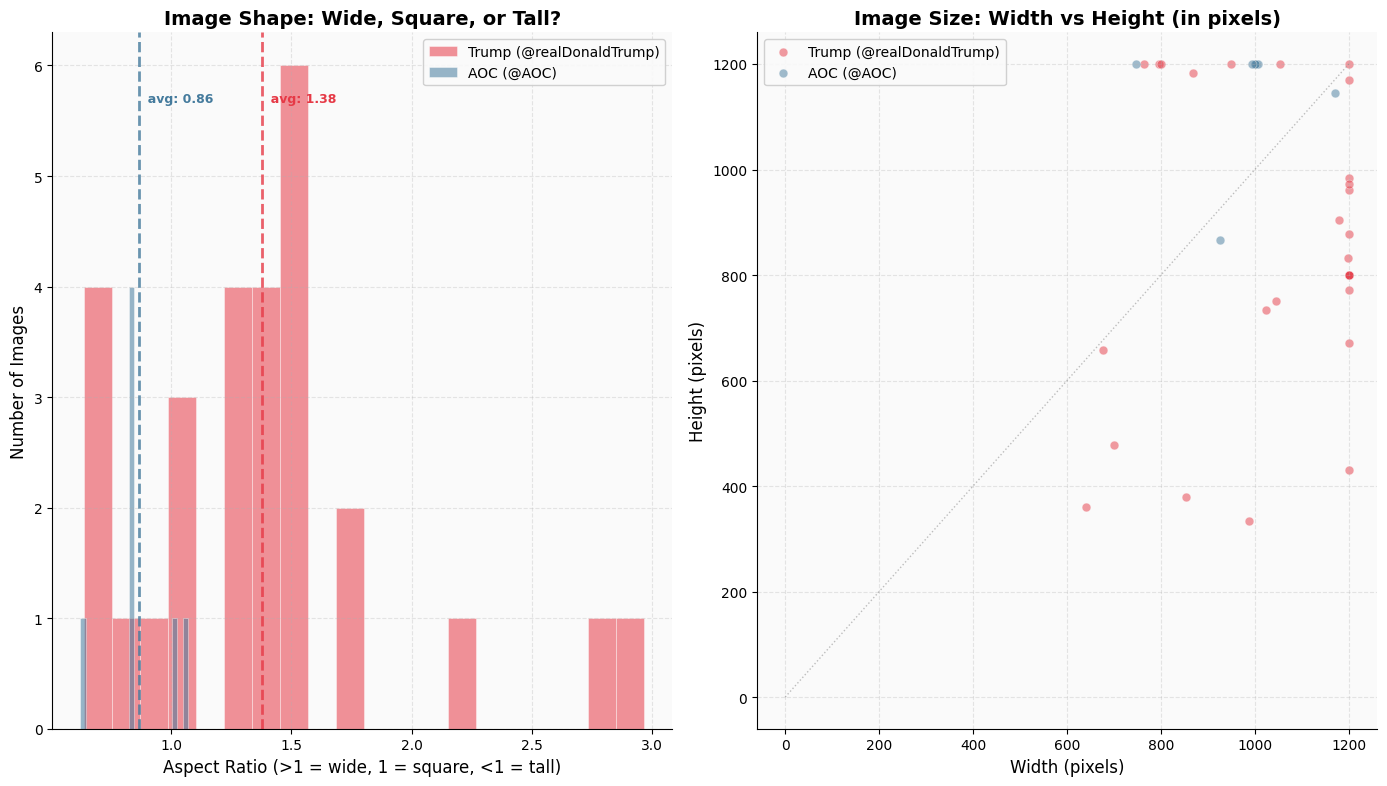


Most common image shapes (aspect ratio rounded to 1 decimal):
  (Reminder: 1.0 = square, >1.0 = wide/landscape, <1.0 = tall/portrait)
  Trump (@realDonaldTrump):
    1.5 (wide/landscape) - 5 images
    1.4 (wide/landscape) - 4 images
    1.2 (wide/landscape) - 3 images
  AOC (@AOC):
    0.8 (tall/portrait) - 4 images
    1.1 (wide/landscape) - 1 images
    0.6 (tall/portrait) - 1 images


In [6]:
# --- Image shape analysis: aspect ratio and dimensions ---

if len(df_images) > 0:
    fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)
    
    # --- Panel 1: What shapes are the images? ---
    ax = axes[0]
    for user in ['trump', 'aoc']:
        user_data = df_images[df_images['user'] == user]['aspect_ratio'].dropna()
        ax.hist(user_data, bins=20, alpha=0.55, color=colors[user],
                edgecolor='white', linewidth=0.5, label=get_user_label(user))
        mean_val = user_data.mean()
        ax.axvline(mean_val, color=colors[user], linestyle='--', linewidth=2, alpha=0.8)
        ax.text(mean_val, ax.get_ylim()[1] * 0.9, f'  avg: {mean_val:.2f}',
                color=colors[user], fontsize=9, fontweight='bold')
    ax.set_title('Image Shape: Wide, Square, or Tall?', fontweight='bold')
    ax.set_xlabel('Aspect Ratio (>1 = wide, 1 = square, <1 = tall)')
    ax.set_ylabel('Number of Images')
    ax.legend()
    
    # --- Panel 2: Actual image dimensions ---
    ax = axes[1]
    for user in ['trump', 'aoc']:
        user_data = df_images[df_images['user'] == user]
        ax.scatter(user_data['width'], user_data['height'],
                   color=colors[user], alpha=0.5, s=40, edgecolor='white',
                   linewidth=0.5, label=get_user_label(user))
    # Add diagonal line for perfect square
    max_dim = max(df_images['width'].max(), df_images['height'].max())
    ax.plot([0, max_dim], [0, max_dim], color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.set_title('Image Size: Width vs Height (in pixels)', fontweight='bold')
    ax.set_xlabel('Width (pixels)')
    ax.set_ylabel('Height (pixels)')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print common shapes
    print("\nMost common image shapes (aspect ratio rounded to 1 decimal):")
    print("  (Reminder: 1.0 = square, >1.0 = wide/landscape, <1.0 = tall/portrait)")
    for u in ['trump', 'aoc']:
        user_data = df_images[df_images['user'] == u]
        rounded = user_data['aspect_ratio'].round(1)
        top = rounded.value_counts().head(3)
        print(f"  {get_user_label(u)}:")
        for ratio, cnt in top.items():
            shape = 'square' if ratio == 1.0 else ('wide/landscape' if ratio > 1 else 'tall/portrait')
            print(f"    {ratio:.1f} ({shape}) - {cnt} images")
else:
    print("No image data available for shape analysis.")

### What does this tell us?

The **shape of an image** is not random -- it reflects the type of content being shared:
- **Wide (landscape) images** are typical of photos from events, rallies, and professional photography
- **Tall (portrait) images** are common for phone screenshots, vertical videos, and some infographics
- **Square images** are often graphics, memes, or images designed specifically for social media

If one politician consistently uses a particular shape, it tells us about their content production process. Professionally produced content tends to be wide/landscape, while more spontaneous or user-generated content tends to be taller.

The scatter plot (width vs. height) also shows whether the politician uses a consistent image size or varies widely, which can indicate whether they have a standardized content production workflow.

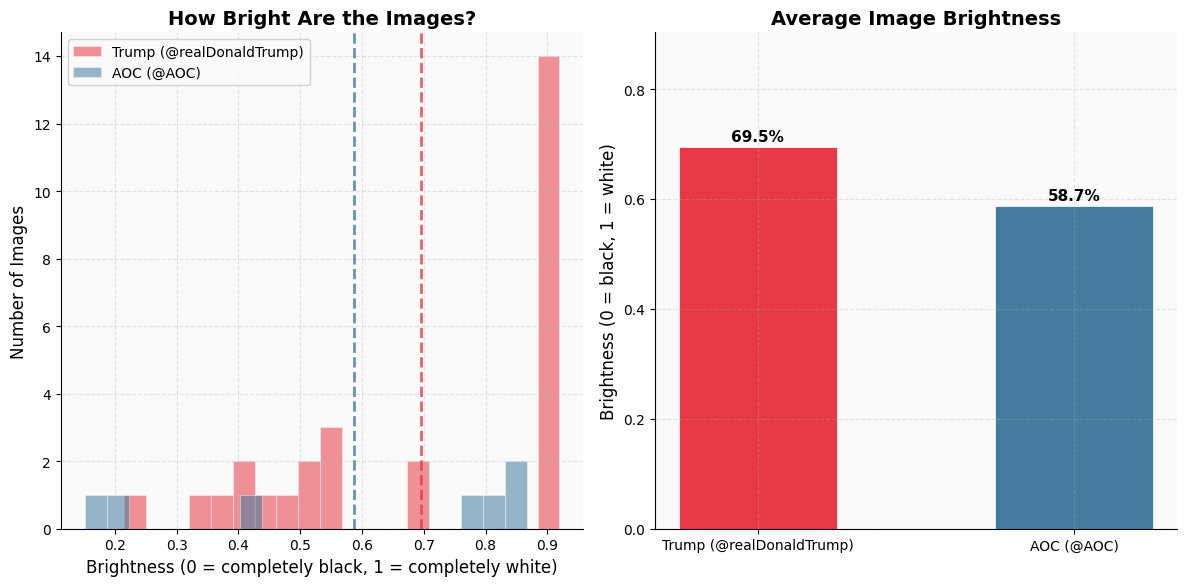


Brightness summary:
  (Higher = brighter/lighter images, Lower = darker images)
  Trump (@realDonaldTrump): average brightness = 69.5%, middle value = 79.3%
  AOC (@AOC): average brightness = 58.7%, middle value = 78.6%


In [7]:
# --- Brightness analysis: How light or dark are the images? ---

if len(df_images) > 0:
    fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)
    
    # --- Panel 1: How brightness values are spread out ---
    ax = axes[0]
    for user in ['trump', 'aoc']:
        user_data = df_images[df_images['user'] == user]['brightness'].dropna()
        ax.hist(user_data, bins=20, alpha=0.55, color=colors[user],
                edgecolor='white', linewidth=0.5, label=get_user_label(user))
        mean_val = user_data.mean()
        ax.axvline(mean_val, color=colors[user], linestyle='--', linewidth=2, alpha=0.8)
    ax.set_title('How Bright Are the Images?', fontweight='bold')
    ax.set_xlabel('Brightness (0 = completely black, 1 = completely white)')
    ax.set_ylabel('Number of Images')
    ax.legend()
    
    # --- Panel 2: Average brightness comparison ---
    ax = axes[1]
    mean_brightness = [df_images[df_images['user'] == u]['brightness'].mean() for u in users]
    user_labels_short = [get_user_label(u) for u in users]
    bars = ax.bar(user_labels_short, mean_brightness, color=[colors[u] for u in users],
                  width=0.5, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, mean_brightness):
        pct = val * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title('Average Image Brightness', fontweight='bold')
    ax.set_ylabel('Brightness (0 = black, 1 = white)')
    ax.set_ylim(0, min(max(mean_brightness) * 1.3, 1.0))
    
    plt.tight_layout()
    plt.show()
    
    # Print interpretation
    print("\nBrightness summary:")
    print("  (Higher = brighter/lighter images, Lower = darker images)")
    for u in users:
        b = df_images[df_images['user'] == u]['brightness']
        print(f"  {get_user_label(u)}: average brightness = {b.mean()*100:.1f}%, middle value = {b.median()*100:.1f}%")
else:
    print("No image data available for brightness analysis.")

### What does this tell us?

Image brightness is part of a politician's **visual tone**:
- **Brighter images** tend to feel more optimistic, open, and positive. Think of bright outdoor photos, well-lit stages, and light-colored backgrounds.
- **Darker images** tend to feel more dramatic, serious, or intense. Think of dimly lit stages, nighttime events, or high-contrast graphics.

If one politician consistently uses brighter imagery, they may be cultivating an optimistic, hopeful visual identity. If another leans darker, they may be going for a more dramatic, high-stakes feel.

Of course, brightness also depends on practical factors (indoor vs. outdoor events, time of day), but consistent patterns across many images suggest intentional visual choices.

---
## 4. Color Palette: What Colors Dominate Their Images?

Color is a powerful tool for how images are used to persuade and communicate. In politics, color carries meaning:
- **Red** is associated with energy, urgency, passion, and (in the US) the Republican Party
- **Blue** is associated with calm, trust, stability, and (in the US) the Democratic Party
- **Green** suggests nature, growth, or environmental themes

Remember: every digital image is made of tiny dots (pixels) that mix **Red, Green, and Blue** light (often abbreviated as RGB). By measuring the average amount of red, green, and blue across all pixels, we can characterize each politician's **color palette** -- the overall color feel of their images.

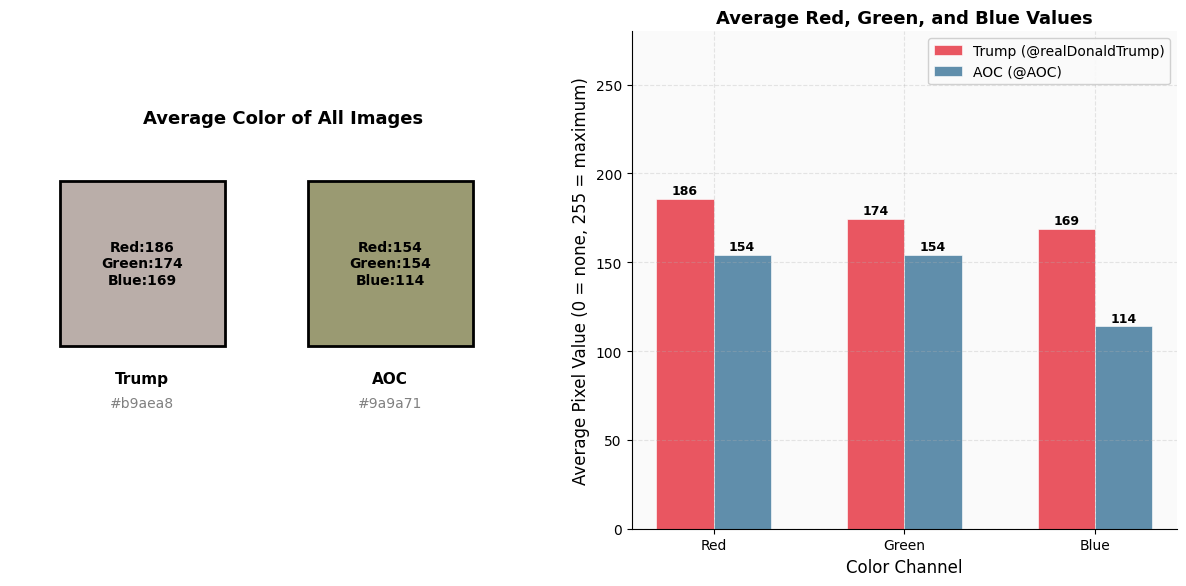

In [8]:
# --- What is the average color of each politician's images? ---

if len(df_images) > 0:
    fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)
    
    # --- Panel 1: Color swatches showing the average color ---
    ax = axes[0]
    avg_colors_per_user = {}
    for idx, user in enumerate(users):
        user_data = df_images[df_images['user'] == user]
        avg_r = user_data['avg_red'].mean() / 255.0
        avg_g = user_data['avg_green'].mean() / 255.0
        avg_b = user_data['avg_blue'].mean() / 255.0
        avg_colors_per_user[user] = (avg_r, avg_g, avg_b)
        
        # Draw a colored rectangle showing the average color
        rect = plt.Rectangle((idx * 1.5, 0), 1.0, 1.0,
                             facecolor=(avg_r, avg_g, avg_b), edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        
        # Label below
        hex_color = '#{:02x}{:02x}{:02x}'.format(
            int(avg_r * 255), int(avg_g * 255), int(avg_b * 255))
        ax.text(idx * 1.5 + 0.5, -0.15, get_user_label(user).split(' (')[0],
                ha='center', va='top', fontsize=11, fontweight='bold')
        ax.text(idx * 1.5 + 0.5, -0.30, hex_color,
                ha='center', va='top', fontsize=10, color='gray')
        ax.text(idx * 1.5 + 0.5, 0.5,
                f'Red:{avg_r*255:.0f}\nGreen:{avg_g*255:.0f}\nBlue:{avg_b*255:.0f}',
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white' if (avg_r + avg_g + avg_b) / 3 < 0.5 else 'black')
    
    ax.set_xlim(-0.3, len(users) * 1.5)
    ax.set_ylim(-0.5, 1.3)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Average Color of All Images', fontweight='bold', fontsize=13)
    
    # --- Panel 2: Bar chart of average Red, Green, Blue values ---
    ax = axes[1]
    x = np.arange(3)  # R, G, B
    bar_width = 0.3
    channel_labels = ['Red', 'Green', 'Blue']
    
    for i, user in enumerate(users):
        user_data = df_images[df_images['user'] == user]
        means = [
            user_data['avg_red'].mean(),
            user_data['avg_green'].mean(),
            user_data['avg_blue'].mean()
        ]
        offset = -bar_width / 2 + i * bar_width
        bars = ax.bar(x + offset, means, width=bar_width,
                      color=colors[user], alpha=0.85,
                      label=get_user_label(user),
                      edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title('Average Red, Green, and Blue Values', fontweight='bold', fontsize=13)
    ax.set_xlabel('Color Channel')
    ax.set_ylabel('Average Pixel Value (0 = none, 255 = maximum)')
    ax.set_xticks(x)
    ax.set_xticklabels(channel_labels)
    ax.set_ylim(0, 280)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No image data available for color analysis.")

### What does this tell us?

The color swatch shows the **overall visual tone** of each politician's image library. Even though any single image might vary, the average across all images reveals a consistent palette.

The bar chart breaks this down further: if one politician has significantly more red in their images, their visual content has a warmer, more energetic feel. If another has more blue, their imagery feels cooler and calmer.

These color choices -- whether intentional or not -- contribute to a politician's **visual brand**. Over time, audiences associate certain colors and tones with certain politicians, reinforcing recognition and identity.

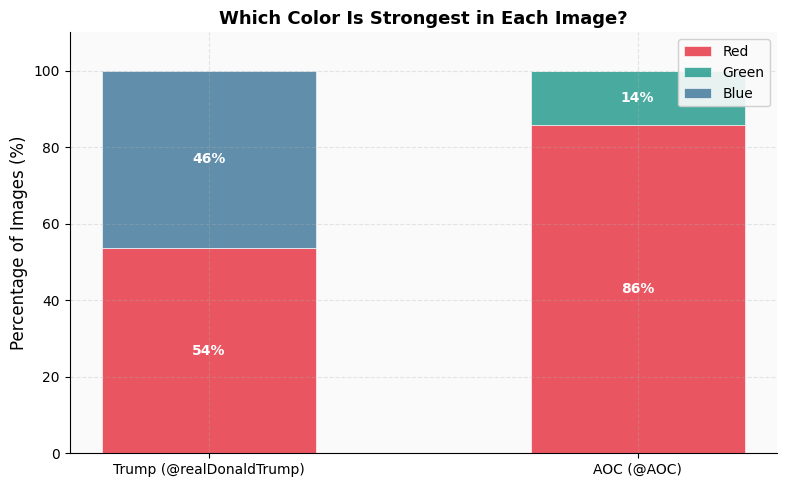


Dominant color breakdown:
  (For each image, which color -- Red, Green, or Blue -- is strongest?)
  Trump (@realDonaldTrump):
    Red: 15 images (53.6%)
    Green: 0 images (0.0%)
    Blue: 13 images (46.4%)
  AOC (@AOC):
    Red: 6 images (85.7%)
    Green: 1 images (14.3%)
    Blue: 0 images (0.0%)


In [9]:
# --- Which color is strongest in each image? ---
# For each image, we check whether Red, Green, or Blue is the dominant color.

if len(df_images) > 0:
    fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)
    
    channel_order = ['R', 'G', 'B']
    channel_display = ['Red', 'Green', 'Blue']
    channel_bar_colors = ['#E63946', '#2A9D8F', '#457B9D']
    
    x = np.arange(len(users))
    bottom = np.zeros(len(users))
    
    for ch_idx, channel in enumerate(channel_order):
        pcts = []
        for user in users:
            user_data = df_images[df_images['user'] == user]
            total = len(user_data)
            ch_count = (user_data['dominant_channel'] == channel).sum()
            pcts.append(ch_count / total * 100 if total > 0 else 0)
        
        bars = ax.bar(x, pcts, bottom=bottom, width=0.5,
                      color=channel_bar_colors[ch_idx], alpha=0.85,
                      label=channel_display[ch_idx],
                      edgecolor='white', linewidth=0.5)
        
        for i, (bar, pct) in enumerate(zip(bars, pcts)):
            if pct >= 5:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bottom[i] + pct / 2,
                        f'{pct:.0f}%', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='white')
        bottom += pcts
    
    ax.set_title('Which Color Is Strongest in Each Image?', fontweight='bold', fontsize=13)
    ax.set_ylabel('Percentage of Images (%)')
    ax.set_xticks(x)
    ax.set_xticklabels([get_user_label(u) for u in users])
    ax.set_ylim(0, 110)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Print exact values
    print("\nDominant color breakdown:")
    print("  (For each image, which color -- Red, Green, or Blue -- is strongest?)")
    for u in users:
        user_data = df_images[df_images['user'] == u]
        total = len(user_data)
        print(f"  {get_user_label(u)}:")
        for ch, name in zip(channel_order, channel_display):
            cnt = (user_data['dominant_channel'] == ch).sum()
            print(f"    {name}: {cnt} images ({cnt/total*100:.1f}%)")
else:
    print("No image data available for dominant color analysis.")

### What does this tell us?

This chart shows the **color tendency** of each politician's images. If most of a politician's images are dominated by red, their visual content has warm tones -- reds, oranges, warm browns. If blue dominates, the images lean toward cooler tones -- blues, grays, cool whites.

In American politics, there is an interesting dimension here: red is the traditional color of the Republican Party, and blue is the traditional color of the Democratic Party. While image colors are not always intentional, a consistent pattern may reinforce a politician's partisan visual identity.

---
## 5. Do Images Help? The Relationship Between Images and Engagement

One of the most important questions for understanding visual strategy is: **do tweets with images actually get more attention than text-only tweets?**

If images consistently lead to more likes, retweets, and replies, it confirms that visual content is an effective tool for reaching audiences. If there is no difference, then images may be more about aesthetics than strategy.

We compare engagement (attention received) for tweets with images versus tweets without images.

C:\Users\Ayrton\AppData\Local\Temp\ipykernel_195492\1917693081.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.5,


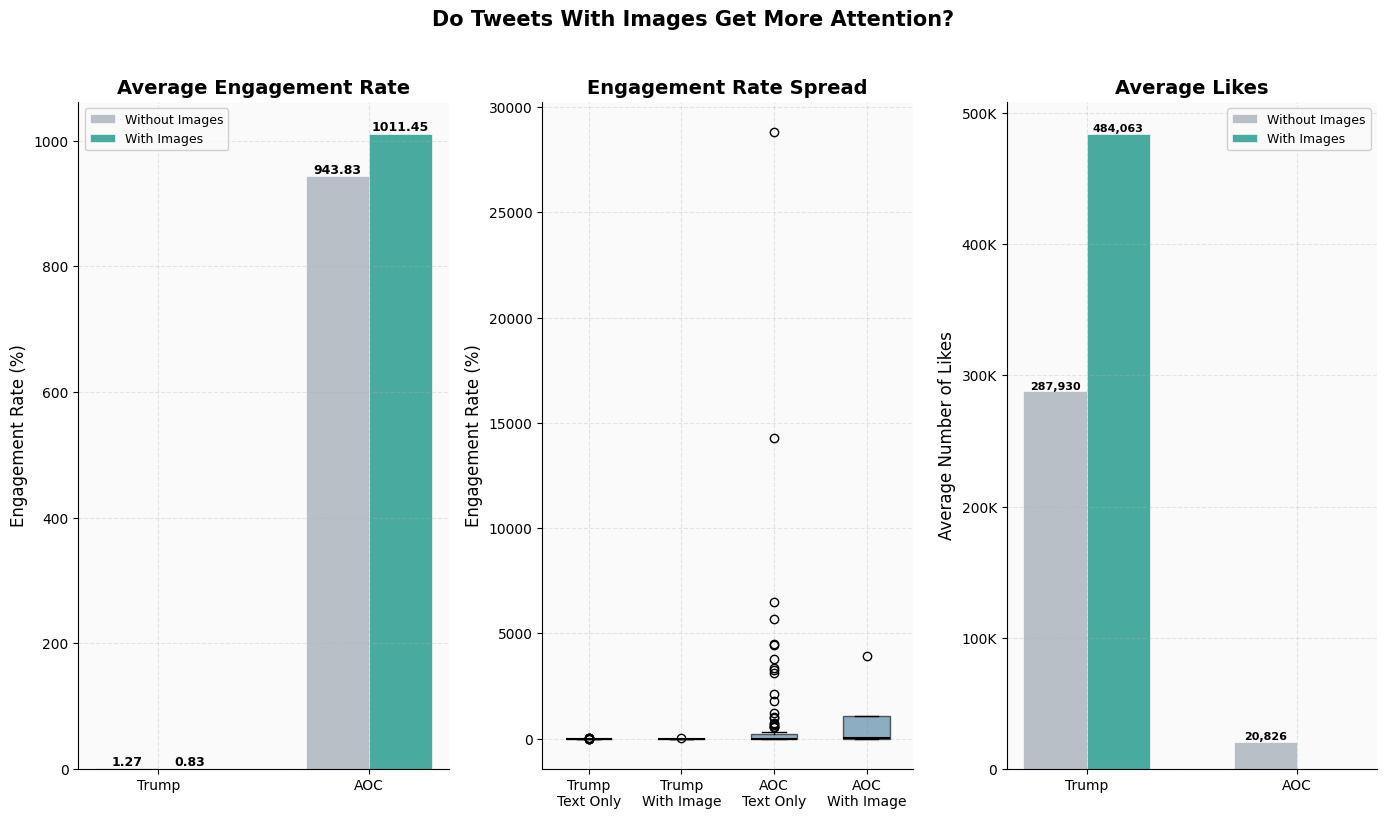


Comparison: Tweets with images vs. text-only tweets
Politician   Type                 Tweets   Avg Engagement    Avg Likes
--------------------------------------------------------------------
Trump        Text Only                75           1.268%     287,930
Trump        With Images              25           0.835%     484,063
AOC          Text Only                96         943.829%      20,826
AOC          With Images               4        1011.447%           0


In [10]:
# --- Do tweets with images get more attention? ---

fig, axes = plt.subplots(1, 3, figsize=FIGURE_SIZE_LARGE)

# Add 'has_image' flag
df['has_image'] = df['image_count'] > 0

# --- Panel 1: Average engagement rate for tweets with vs without images ---
ax = axes[0]
x = np.arange(len(users))
bar_width = 0.3
group_colors = ['#ADB5BD', '#2A9D8F']
group_labels_display = ['Without Images', 'With Images']

for g_idx, has_img in enumerate([False, True]):
    means = []
    for user in users:
        user_data = df[(df['user'] == user) & (df['has_image'] == has_img)]
        means.append(user_data['engagement_rate'].mean() if len(user_data) > 0 else 0)
    offset = -bar_width / 2 + g_idx * bar_width
    bars = ax.bar(x + offset, means, width=bar_width,
                  color=group_colors[g_idx], alpha=0.85,
                  label=group_labels_display[g_idx],
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, means):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Average Engagement Rate', fontweight='bold')
ax.set_ylabel('Engagement Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels([get_user_label(u).split(' (')[0] for u in users])
ax.legend(fontsize=9)

# --- Panel 2: Box plot showing engagement spread ---
ax = axes[1]
box_data = []
box_labels = []
box_colors_list = []
for user in users:
    for has_img, label_suffix in [(False, 'Text Only'), (True, 'With Image')]:
        subset = df[(df['user'] == user) & (df['has_image'] == has_img)]['engagement_rate'].dropna()
        if len(subset) > 0:
            box_data.append(subset.values)
            short_name = 'Trump' if user == 'trump' else 'AOC'
            box_labels.append(f'{short_name}\n{label_suffix}')
            box_colors_list.append(colors[user])

if box_data:
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'linewidth': 1.5})
    for patch, c in zip(bp['boxes'], box_colors_list):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)

ax.set_title('Engagement Rate Spread', fontweight='bold')
ax.set_ylabel('Engagement Rate (%)')
ax.tick_params(axis='x', rotation=0)

# --- Panel 3: Average likes for tweets with vs without images ---
ax = axes[2]
for g_idx, has_img in enumerate([False, True]):
    means = []
    for user in users:
        user_data = df[(df['user'] == user) & (df['has_image'] == has_img)]
        means.append(user_data['favorite_count'].mean() if len(user_data) > 0 else 0)
    offset = -bar_width / 2 + g_idx * bar_width
    bars = ax.bar(x + offset, means, width=bar_width,
                  color=group_colors[g_idx], alpha=0.85,
                  label=group_labels_display[g_idx],
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, means):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Average Likes', fontweight='bold')
ax.set_ylabel('Average Number of Likes')
ax.set_xticks(x)
ax.set_xticklabels([get_user_label(u).split(' (')[0] for u in users])
ax.legend(fontsize=9)
format_large_numbers(ax)

fig.suptitle('Do Tweets With Images Get More Attention?', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Print summary table
print("\nComparison: Tweets with images vs. text-only tweets")
print(f"{'Politician':<12} {'Type':<18} {'Tweets':>8} {'Avg Engagement':>16} {'Avg Likes':>12}")
print('-' * 68)
for user in users:
    label = get_user_label(user).split(' (')[0]
    for has_img, group_name in [(False, 'Text Only'), (True, 'With Images')]:
        subset = df[(df['user'] == user) & (df['has_image'] == has_img)]
        if len(subset) > 0:
            print(f"{label:<12} {group_name:<18} {len(subset):>8} "
                  f"{subset['engagement_rate'].mean():>15.3f}% "
                  f"{subset['favorite_count'].mean():>11,.0f}")

### What does this tell us?

This comparison is one of the most practically important findings in the notebook. If tweets with images consistently receive higher engagement (more likes, retweets, replies), it confirms that **visual content is a strategic advantage** on social media.

Pay attention to whether the "image boost" is the same for both politicians or different. If one politician benefits more from images than the other, it may mean their audience is particularly responsive to visual content, or that their images are of higher quality and relevance.

The box plot in the middle helps us see not just the average, but the full range -- are image tweets *consistently* better, or is the average being pulled up by a few viral hits?

---
## 6. When Do They Post Images? Timing Patterns

The timing of image posts may differ from the timing of text-only posts. Politicians (or their social media teams) might schedule visual content for **peak audience hours** to maximize impact, while posting text updates at other times.

We look at two timing dimensions:
- **Hour of day** (in UTC, which is the universal time standard used online)
- **Day of the week**

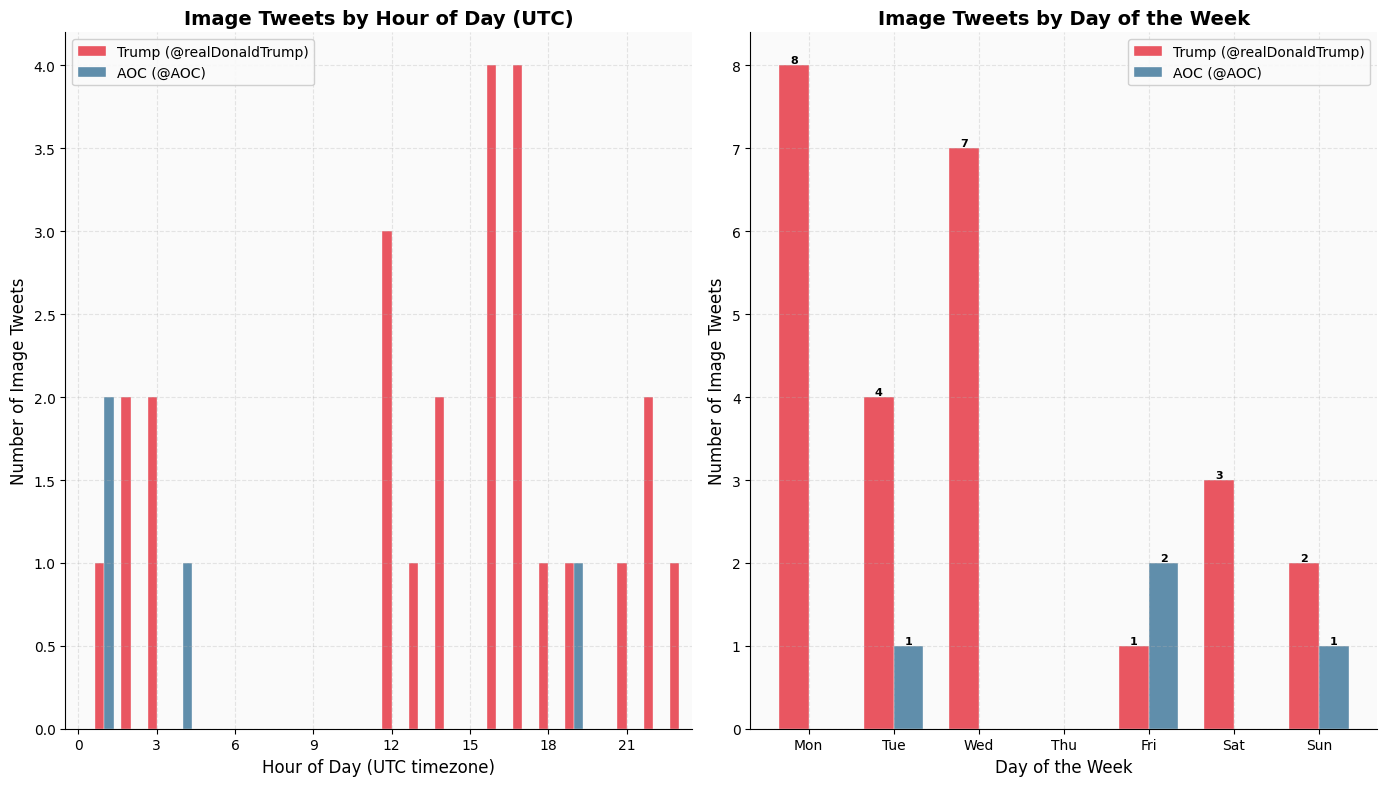


Most common hour for posting images (UTC):
  Trump (@realDonaldTrump): 16:00 UTC
  AOC (@AOC): 1:00 UTC


In [11]:
# --- When do they post image tweets? ---

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

# --- Panel 1: Hour-of-day distribution for image tweets ---
ax = axes[0]
x_hours = np.arange(24)
bar_width = 0.35

for i, user in enumerate(users):
    user_img_tweets = df_with_images[df_with_images['user'] == user]
    hour_counts = user_img_tweets['hour'].value_counts().reindex(range(24), fill_value=0)
    offset = -bar_width / 2 + i * bar_width
    ax.bar(x_hours + offset, hour_counts.values,
           width=bar_width, color=colors[user], alpha=0.85,
           label=get_user_label(user), edgecolor='white', linewidth=0.3)

ax.set_title('Image Tweets by Hour of Day (UTC)', fontweight='bold')
ax.set_xlabel('Hour of Day (UTC timezone)')
ax.set_ylabel('Number of Image Tweets')
ax.set_xticks(range(0, 24, 3))
ax.set_xlim(-0.5, 23.5)
ax.legend()

# --- Panel 2: Day-of-week distribution for image tweets ---
ax = axes[1]
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_abbr = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
x_days = np.arange(len(day_order))
bar_width = 0.35

for i, user in enumerate(users):
    user_img_tweets = df_with_images[df_with_images['user'] == user]
    day_counts = user_img_tweets['day_name'].value_counts().reindex(day_order, fill_value=0)
    offset = -bar_width / 2 + i * bar_width
    bars = ax.bar(x_days + offset, day_counts.values,
                  width=bar_width, color=colors[user], alpha=0.85,
                  label=get_user_label(user), edgecolor='white', linewidth=0.3)
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Image Tweets by Day of the Week', fontweight='bold')
ax.set_xlabel('Day of the Week')
ax.set_ylabel('Number of Image Tweets')
ax.set_xticks(x_days)
ax.set_xticklabels(day_abbr)
ax.legend()

plt.tight_layout()
plt.show()

# Print peak hours
print("\nMost common hour for posting images (UTC):")
for u in users:
    user_img = df_with_images[df_with_images['user'] == u]
    if len(user_img) > 0:
        peak_hour = user_img['hour'].mode().iloc[0] if len(user_img['hour'].mode()) > 0 else 'N/A'
        print(f"  {get_user_label(u)}: {peak_hour}:00 UTC")

### What does this tell us?

Timing patterns can reveal **strategic scheduling** of visual content. If image tweets cluster at certain hours or days, the politician (or their social media team) may be deliberately scheduling visual posts when the most people are online.

Differences from overall posting patterns are especially interesting: if a politician posts text throughout the day but reserves images for peak hours, it suggests they understand that visual content has the most impact when the largest audience is watching.

Weekend vs. weekday patterns can also be revealing -- more casual, personal content on weekends vs. professional, policy-focused imagery during the work week.

---
## 7. Top-Performing Image Tweets

Finally, let us look at the **specific image tweets that performed best** -- the ones that got the most engagement (likes, retweets, replies combined). By examining both the image and the text of these top performers, we can understand what makes certain visual content resonate with audiences.

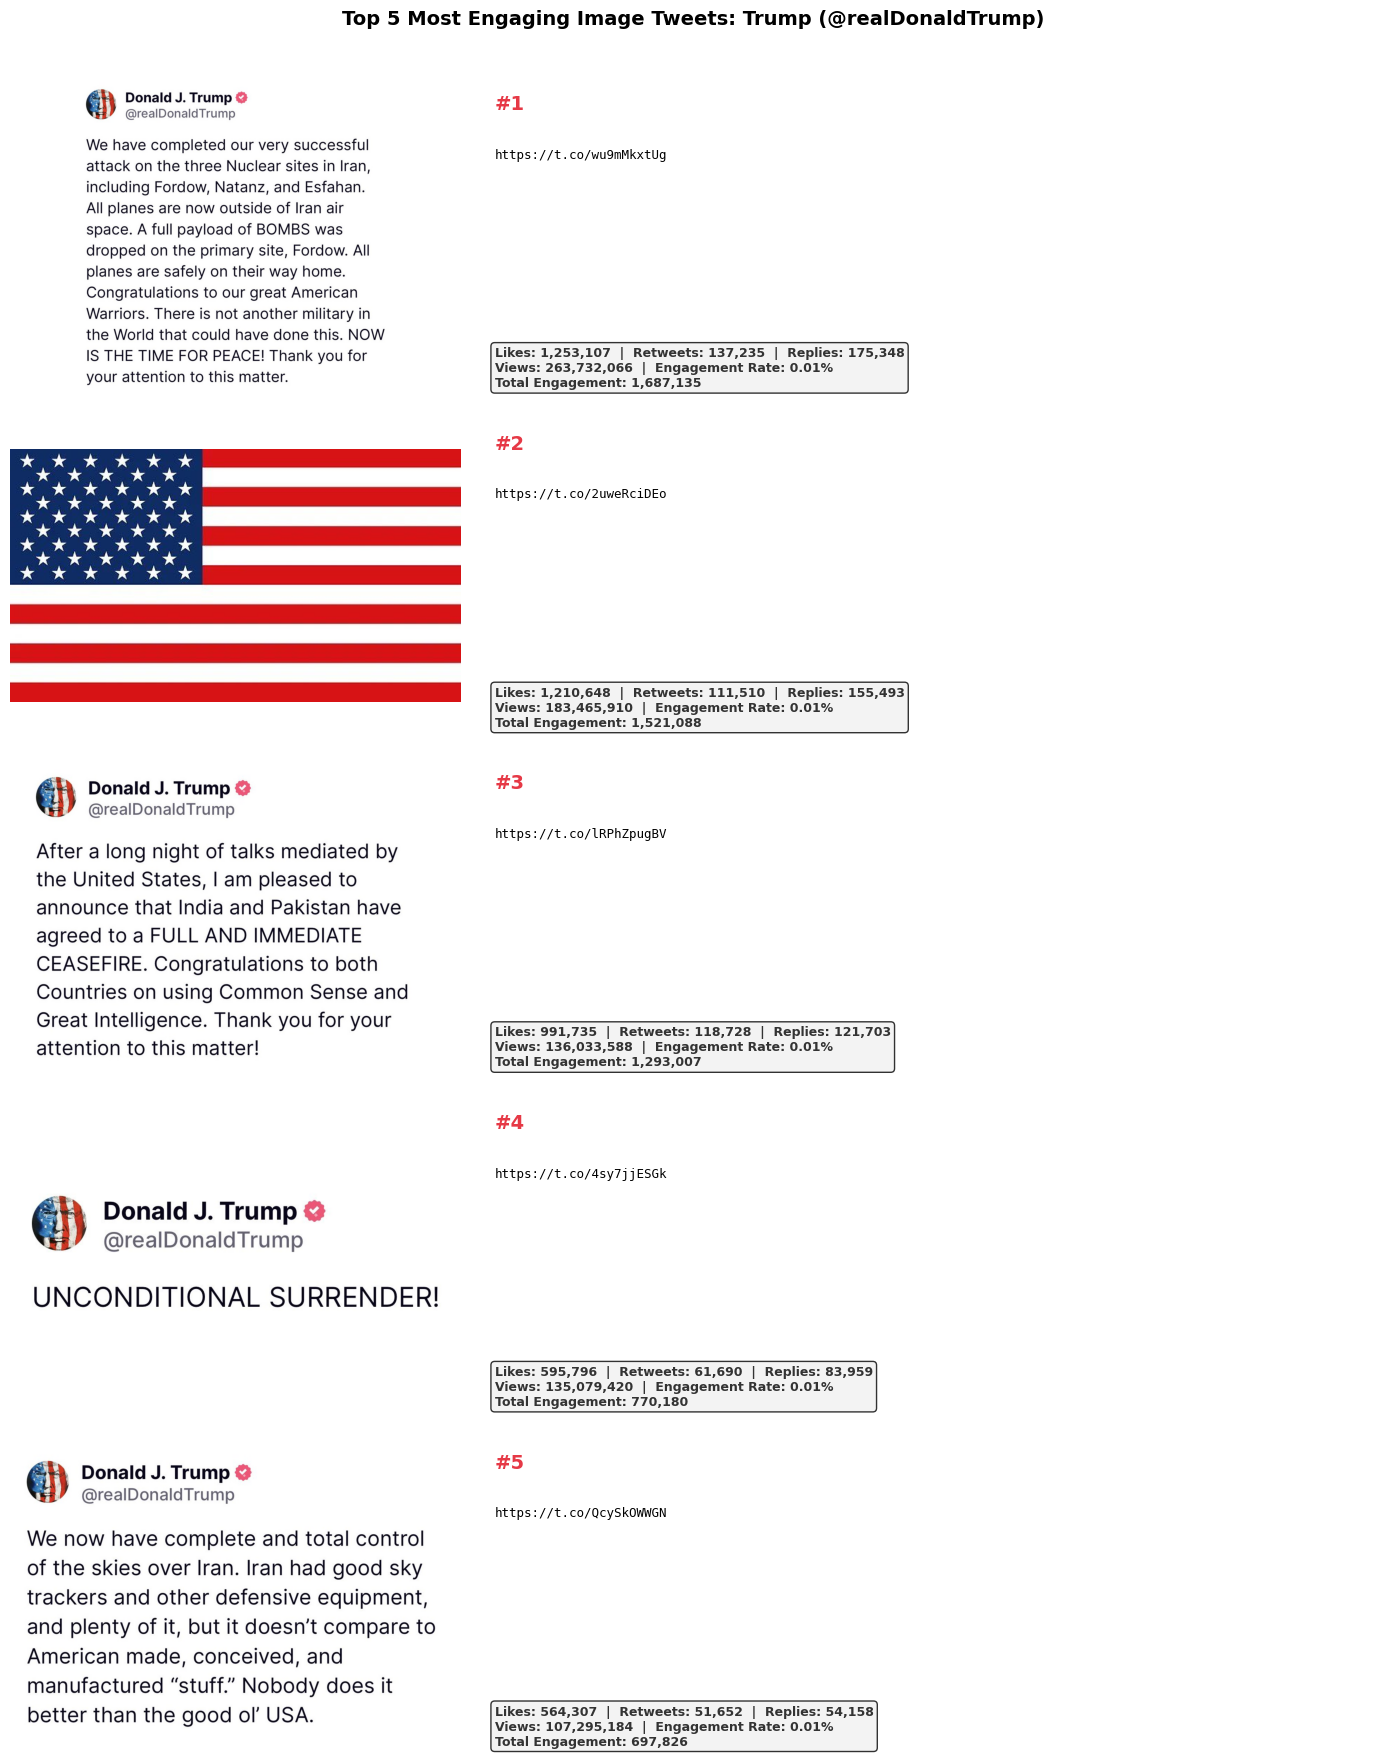

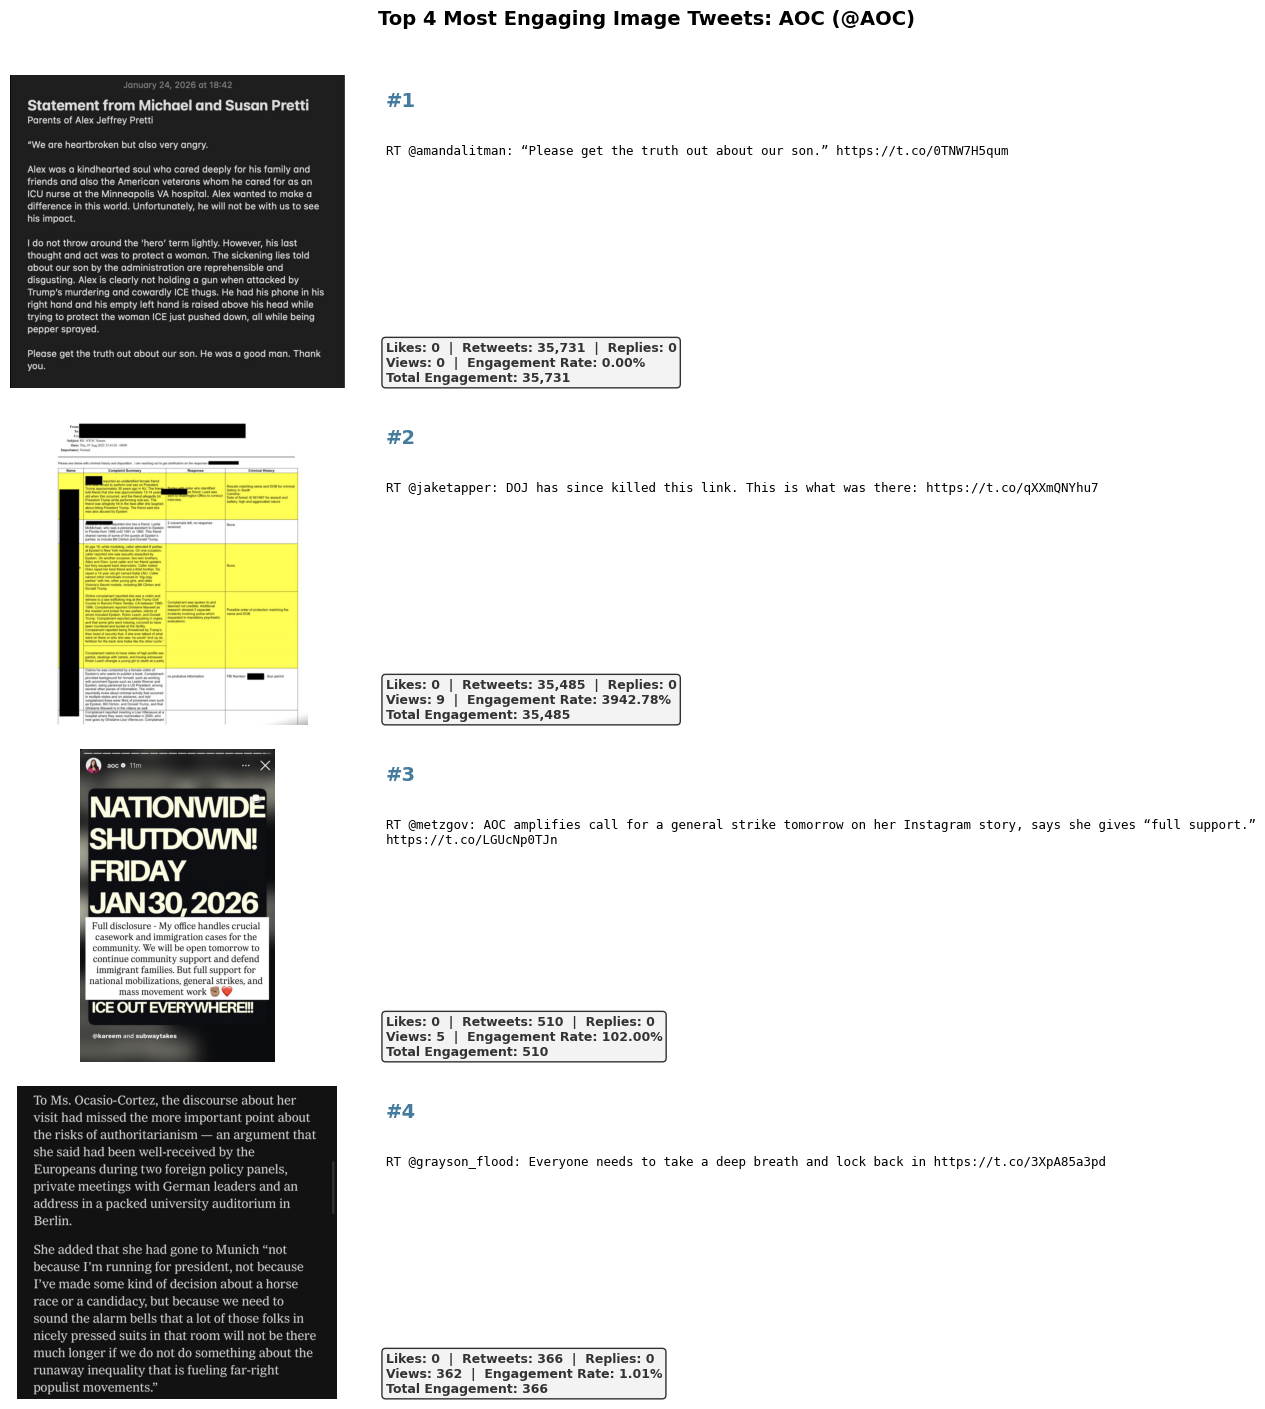

In [12]:
# --- Top 5 image tweets by total engagement ---

TOP_N = 5

for user in ['trump', 'aoc']:
    user_img_tweets = df_with_images[df_with_images['user'] == user].copy()
    
    if len(user_img_tweets) == 0:
        print(f"No image tweets available for {get_user_label(user)}")
        continue
    
    top_tweets = user_img_tweets.nlargest(TOP_N, 'total_engagement')
    n_show = len(top_tweets)
    
    fig, axes = plt.subplots(n_show, 2, figsize=(14, n_show * 3.5),
                             gridspec_kw={'width_ratios': [1, 2]})
    fig.suptitle(f'Top {n_show} Most Engaging Image Tweets: {get_user_label(user)}',
                 fontweight='bold', fontsize=14, y=1.01)
    
    if n_show == 1:
        axes = np.array([axes])
    
    for idx, (_, row) in enumerate(top_tweets.iterrows()):
        ax_img = axes[idx, 0]
        ax_text = axes[idx, 1]
        
        # Try to load the image for this tweet
        image_loaded = False
        if pd.notna(row.get('image_paths', None)) and str(row['image_paths']).strip():
            paths = str(row['image_paths']).split(',')
            for img_path_str in paths:
                img_path_str = img_path_str.strip()
                if img_path_str:
                    try:
                        img = Image.open(img_path_str)
                        ax_img.imshow(img)
                        image_loaded = True
                        img.close()
                        break
                    except Exception:
                        pass
        
        # Fallback: search in inventory by tweet_id
        if not image_loaded:
            tweet_id_str = str(row['tweet_id'])
            for inv_path in image_inventory.get(user, []):
                if inv_path.stem.startswith(tweet_id_str):
                    try:
                        img = Image.open(inv_path)
                        ax_img.imshow(img)
                        image_loaded = True
                        img.close()
                        break
                    except Exception:
                        pass
        
        if not image_loaded:
            ax_img.text(0.5, 0.5, 'Image\nNot Available',
                        ha='center', va='center', fontsize=12,
                        color='gray', transform=ax_img.transAxes)
            ax_img.set_facecolor('#f5f5f5')
        
        ax_img.axis('off')
        
        # Text and metrics panel
        text_content = str(row.get('text', ''))[:200]
        if len(str(row.get('text', ''))) > 200:
            text_content += '...'
        
        metrics_str = (
            f"Likes: {row['favorite_count']:,.0f}  |  "
            f"Retweets: {row['retweet_count']:,.0f}  |  "
            f"Replies: {row['reply_count']:,.0f}\n"
            f"Views: {row['view_count']:,.0f}  |  "
            f"Engagement Rate: {row['engagement_rate']:.2f}%\n"
            f"Total Engagement: {row['total_engagement']:,.0f}"
        )
        
        ax_text.text(0.02, 0.95, f"#{idx+1}", fontsize=14, fontweight='bold',
                     color=colors[user], transform=ax_text.transAxes,
                     va='top')
        ax_text.text(0.02, 0.78, text_content, fontsize=9,
                     transform=ax_text.transAxes, va='top',
                     wrap=True, family='monospace')
        ax_text.text(0.02, 0.15, metrics_str, fontsize=9,
                     transform=ax_text.transAxes, va='top',
                     fontweight='bold', color='#333333',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))
        ax_text.axis('off')
    
    plt.tight_layout()
    plt.show()
    print()

### What does this tell us?

The top-performing image tweets reveal **what visual content resonates most** with each audience. Look for patterns:
- Do the most successful images show the politician in action (rallies, speeches) or in personal moments?
- Are the top images polished professional photos or more casual/candid shots?
- Do infographics or text-based images perform well, or is it primarily photographs?
- Is there a common theme (patriotism, opposition, humor, policy) among the top performers?

These patterns reveal what each audience values most and suggest what kind of visual content works best for political communication.

---
## 8. Visual Strategy Summary

This table brings together the key visual metrics for direct comparison, showing how each politician's image strategy stacks up.

In [13]:
# --- Summary comparison table ---

summary_rows = []

for user in users:
    user_all = df[df['user'] == user]
    user_img = df_with_images[df_with_images['user'] == user]
    user_no_img = df_without_images[df_without_images['user'] == user]
    user_img_props = df_images[df_images['user'] == user] if len(df_images) > 0 else pd.DataFrame()
    
    total = len(user_all)
    pct_images = len(user_img) / total * 100 if total > 0 else 0
    avg_img_per_tweet = user_all['image_count'].mean() if total > 0 else 0
    
    # Image properties
    mean_brightness = user_img_props['brightness'].mean() if len(user_img_props) > 0 else np.nan
    
    # Average color as hex
    if len(user_img_props) > 0:
        avg_r = int(user_img_props['avg_red'].mean())
        avg_g = int(user_img_props['avg_green'].mean())
        avg_b = int(user_img_props['avg_blue'].mean())
        avg_hex = f'#{avg_r:02x}{avg_g:02x}{avg_b:02x}'
    else:
        avg_hex = 'N/A'
    
    # Engagement rates
    eng_rate_img = user_img['engagement_rate'].mean() if len(user_img) > 0 else np.nan
    eng_rate_no_img = user_no_img['engagement_rate'].mean() if len(user_no_img) > 0 else np.nan
    
    # Engagement boost from images
    if eng_rate_no_img > 0 and not np.isnan(eng_rate_img) and not np.isnan(eng_rate_no_img):
        eng_boost = ((eng_rate_img - eng_rate_no_img) / eng_rate_no_img) * 100
    else:
        eng_boost = np.nan
    
    # Most common posting hour for image tweets
    if len(user_img) > 0 and len(user_img['hour'].mode()) > 0:
        peak_hour = f"{user_img['hour'].mode().iloc[0]}:00 UTC"
    else:
        peak_hour = 'N/A'
    
    summary_rows.append({
        'Metric': get_user_label(user),
        '% Tweets with Images': f'{pct_images:.1f}%',
        'Avg Images per Tweet': f'{avg_img_per_tweet:.2f}',
        'Avg Brightness': f'{mean_brightness*100:.1f}%' if not np.isnan(mean_brightness) else 'N/A',
        'Average Color': avg_hex,
        'Engagement (With Images)': f'{eng_rate_img:.3f}%' if not np.isnan(eng_rate_img) else 'N/A',
        'Engagement (Text Only)': f'{eng_rate_no_img:.3f}%' if not np.isnan(eng_rate_no_img) else 'N/A',
        'Image Engagement Boost': f'{eng_boost:+.1f}%' if not np.isnan(eng_boost) else 'N/A',
        'Peak Image Posting Hour': peak_hour
    })

summary_df = pd.DataFrame(summary_rows).set_index('Metric').T
summary_df.index.name = 'Visual Metric'

# Style the table
def style_visual_summary(styler):
    styler.set_caption('Visual Strategy Comparison: Trump vs AOC')
    styler.set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]},
    ])
    trump_col = [c for c in summary_df.columns if 'trump' in c.lower() or 'Trump' in c]
    aoc_col = [c for c in summary_df.columns if 'aoc' in c.lower() or 'AOC' in c]
    if trump_col:
        styler.set_properties(subset=trump_col, **{'background-color': '#fce4e4'})
    if aoc_col:
        styler.set_properties(subset=aoc_col, **{'background-color': '#e4ecf4'})
    return styler

display(summary_df.style.pipe(style_visual_summary))

# Also print plain text
print("\nPlain text summary:")
print(summary_df.to_string())

Metric,Trump (@realDonaldTrump),AOC (@AOC)
Visual Metric,,
% Tweets with Images,25.0%,4.0%
Avg Images per Tweet,0.28,0.07
Avg Brightness,69.5%,58.7%
Average Color,#b9aea8,#9a9a71
Engagement (With Images),0.835%,1011.447%
Engagement (Text Only),1.268%,943.829%
Image Engagement Boost,-34.2%,+7.2%
Peak Image Posting Hour,16:00 UTC,1:00 UTC



Plain text summary:
Metric                   Trump (@realDonaldTrump) AOC (@AOC)
Visual Metric                                               
% Tweets with Images                        25.0%       4.0%
Avg Images per Tweet                         0.28       0.07
Avg Brightness                              69.5%      58.7%
Average Color                             #b9aea8    #9a9a71
Engagement (With Images)                   0.835%  1011.447%
Engagement (Text Only)                     1.268%   943.829%
Image Engagement Boost                     -34.2%      +7.2%
Peak Image Posting Hour                 16:00 UTC   1:00 UTC


---
## 9. Key Takeaways: How Visual Strategy Supports Political Messaging

After analyzing hundreds of images from Trump's and AOC's Twitter/X accounts, here is what we learned about how politicians use visual content:

**1. Image usage reflects fundamentally different communication strategies.** The frequency with which each politician includes images reveals their approach to visual communication. One may treat images as essential to every message, while the other reserves them for specific types of content. These choices shape how audiences encounter and process their messages in social media feeds.

**2. Image brightness and color create a consistent visual identity.** The average brightness and color palette of a politician's images are not random -- they contribute to an overall "look and feel" that audiences come to associate with that politician. Brighter images may project optimism, while darker images may convey seriousness or drama. Color tendencies can reinforce partisan associations (red/Republican, blue/Democratic).

**3. Images are a proven engagement booster -- but not equally for everyone.** Comparing engagement rates for tweets with and without images reveals the strategic value of visual content. If one politician gets a larger engagement boost from images, their audience may be particularly responsive to visual stimulation, or their images may simply be more compelling.

**4. Image shapes reveal content production choices.** The aspect ratios of images tell us whether a politician favors professionally produced landscape photos (typical of events and official photography), phone-style vertical content (suggesting spontaneity), or square graphics (often designed for social media). These production choices communicate professionalism, authenticity, or digital savviness.

**5. The timing of image posts suggests strategic scheduling.** When image tweets cluster at specific hours or days, it indicates deliberate scheduling rather than spontaneous posting. Social media teams understand that visual content has the most impact during peak audience hours.

**6. Top-performing images reveal what resonates with each audience.** The specific image tweets that generated the most engagement show us what each community responds to most strongly. Whether it is rally photos, policy graphics, personal moments, or opposition memes, the most popular images reveal the values and preferences of each political audience.

**7. Visual strategy is inseparable from political messaging.** Images are not mere decoration -- they are a core component of how politicians communicate their identity, values, and message. The visual choices we have analyzed (what to show, how bright, what colors, how often, when to post) are all part of a broader strategy for how images are used to persuade and communicate in the digital age.

---
*This visual analysis complements the text, engagement, and community analyses from previous notebooks, building toward a comprehensive picture of how Trump and AOC use digital media for political communication.*